# 2 · The Base MMM — *What is each channel worth?*

> **Chapter 2 of the Aurora story.** With the causal groundwork laid, we fit `mmm_framework`'s core
> **Bayesian** MMM and read it the way an analyst would: contributions and ROAS **with honest
> uncertainty**, where the next dollar goes, and a what-if. We'll also see — honestly — what the base
> model *can't* see yet.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
from loguru import logger
logger.remove(); logger.add(sys.stderr, level="ERROR")   # quiet framework logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aurora import generate_aurora, CHANNELS, PRODUCTS, PALETTE, CHANNEL_COLORS

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
ACCENT, INK, MUTED = PALETTE["accent"], PALETTE["ink"], PALETTE["muted"]

aurora = generate_aurora()      # the one dataset every chapter shares

## Fit the model

One model, demand-controlled (the back-door we identified in Chapter 1), with yearly seasonality and a
linear trend. Bayesian sampling gives a full posterior — not a point estimate.

In [2]:
from mmm_framework import BayesianMMM, ModelConfigBuilder, SeasonalityConfigBuilder, TrendConfig, TrendType
from mmm_framework.analysis import MMMAnalyzer

panel = aurora.base_panel(control_demand=True)
model_config = (ModelConfigBuilder().bayesian_pymc()
                .with_chains(2).with_draws(600).with_tune(600).with_target_accept(0.9)
                .with_seasonality_builder(SeasonalityConfigBuilder().with_yearly(order=2)).build())

mmm = BayesianMMM(panel, model_config, TrendConfig(type=TrendType.LINEAR))
results = mmm.fit(draws=600, tune=600, chains=2, cores=1, random_seed=0)
print("fitted:", mmm.n_channels, "channels ·", mmm.n_obs, "weeks")

Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, trend_slope, season_yearly, adstock_alpha_TV, sat_lam_TV, beta_TV, adstock_alpha_Search, sat_lam_Search, beta_Search, adstock_alpha_Social, sat_lam_Social, beta_Social, adstock_alpha_Display, sat_lam_Display, beta_Display, beta_controls, sigma]


Output()

Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 12 seconds.


There were 8 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


fitted: 4 channels · 104 weeks


## Did it converge? (honest uncertainty starts here)

Before trusting a number, check the diagnostics. `R̂≈1` and healthy effective sample size mean the
chains agree; divergences flag geometry problems. *(These small-draw runs are for speed — real analyses
use ≥4 chains and ≥1000 draws.)*

In [3]:
d = results.diagnostics
print(f"R̂ max         {d['rhat_max']:.3f}   (want < 1.01)")
print(f"ESS bulk min   {d['ess_bulk_min']:.0f}    (want > 400)")
print(f"divergences    {d['divergences']}      (want 0)")
results.summary(var_names=[f"beta_{c}" for c in CHANNELS]).round(3)

R̂ max         1.006   (want < 1.01)
ESS bulk min   272    (want > 400)
divergences    8      (want 0)


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta_TV,1.134,0.863,0.179,2.698,790.342,699.657,0.999,0.030,0.033
beta_Search,1.561,1.074,0.264,3.463,430.858,654.149,1.000,0.049,0.039
beta_Social,1.228,0.920,0.196,2.956,599.239,677.449,1.000,0.035,0.040
beta_Display,0.992,0.734,0.154,2.430,778.822,665.138,1.006,0.023,0.024


The table is the numbers; here is their *shape*. Every ROAS below is a summary of these posterior
coefficient distributions — wide bands mean honest uncertainty, not a single confident point.

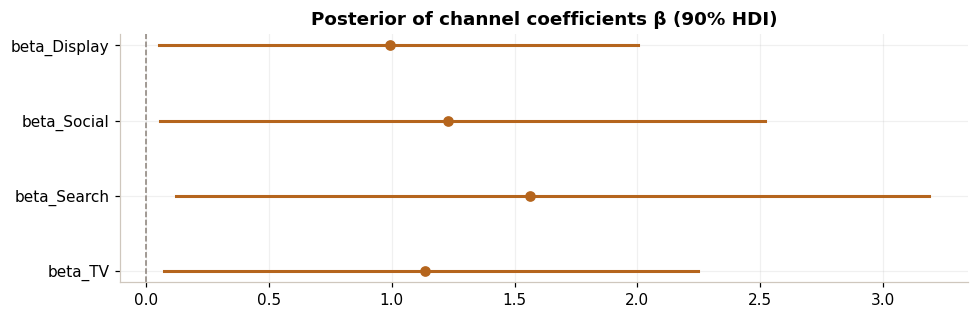

In [4]:
# Posterior of each channel's coefficient — the uncertainty behind every ROAS number.
import arviz as az
from mmm_framework.utils import arviz_compat
_beta = [f"beta_{c}" for c in CHANNELS]
_post = results.trace.posterior
_c = ACCENT if isinstance(ACCENT, str) else (ACCENT[0] if ACCENT else "#4b6584")
# arviz 1.x plot_forest dropped ax/hdi_prob/colors/figsize and returns a PlotCollection;
# draw the forest directly so it keeps composing into a matplotlib axis.
fig, ax = plt.subplots(figsize=(9, 3.0))
for _yi, _v in enumerate(_beta):
    _s = _post[_v].values.ravel()
    _lo, _hi = arviz_compat.hdi_bounds(_s, 0.9)
    ax.plot([_lo, _hi], [_yi, _yi], color=_c, lw=2)
    ax.plot([float(_s.mean())], [_yi], "o", color=_c)
ax.set_yticks(range(len(_beta))); ax.set_yticklabels(_beta)
ax.axvline(0, color=MUTED, ls="--", lw=1)
ax.set_title("Posterior of channel coefficients β (90% HDI)")
plt.tight_layout(); plt.show()


## How much of this came from the data vs our priors?

A posterior interval tells you what to believe *after* the fit — not how much of that belief is the **data**
talking versus the **prior**. The honest check is **prior → posterior learning**: for each parameter,
**contraction** $c = 1 - \mathrm{Var}_{\text{post}}/\mathrm{Var}_{\text{prior}}$ ($c \to 1$ = the data pinned
it; $c \approx 0$ = prior-dominated) and the prior↔posterior **overlap** ($\to 1$ = posterior indistinguishable
from the prior). `compute_parameter_learning` sorts the most prior-dominated parameters to the top.

Sampling: [adstock_alpha_Display, adstock_alpha_Search, adstock_alpha_Social, adstock_alpha_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


,parameter,prior_mean,prior_sd,post_mean,post_sd,contraction,contraction_robust,overlap,shift_z,post_ess_bulk,verdict
0,adstock_alpha_Search,0.260,0.196,0.523,0.281,-1.068,-1.900,0.561,1.349,377.150,relocated
1,adstock_alpha_TV,0.255,0.194,0.389,0.269,-0.935,-1.724,0.753,0.690,854.547,weak
2,adstock_alpha_Display,0.253,0.193,0.378,0.255,-0.740,-1.233,0.775,0.648,764.046,weak
3,adstock_alpha_Social,0.248,0.194,0.403,0.253,-0.692,-1.474,0.704,0.798,528.297,weak
4,beta_Search,1.517,1.006,1.561,1.074,-0.138,-0.537,0.862,0.044,430.858,prior-dominated
5,beta_Social,1.491,0.959,1.228,0.920,0.080,0.257,0.851,-0.274,599.239,prior-dominated
6,beta_TV,1.481,0.972,1.134,0.863,0.211,0.215,0.808,-0.357,790.342,moderate
7,beta_Display,1.488,1.022,0.992,0.734,0.484,0.510,0.756,-0.485,778.822,moderate
8,intercept,-0.007,0.487,-1.836,0.295,0.632,0.685,0.018,-3.759,564.171,strong
9,sat_lam_TV,1.930,1.901,0.593,0.922,0.765,0.932,0.544,-0.703,760.396,strong


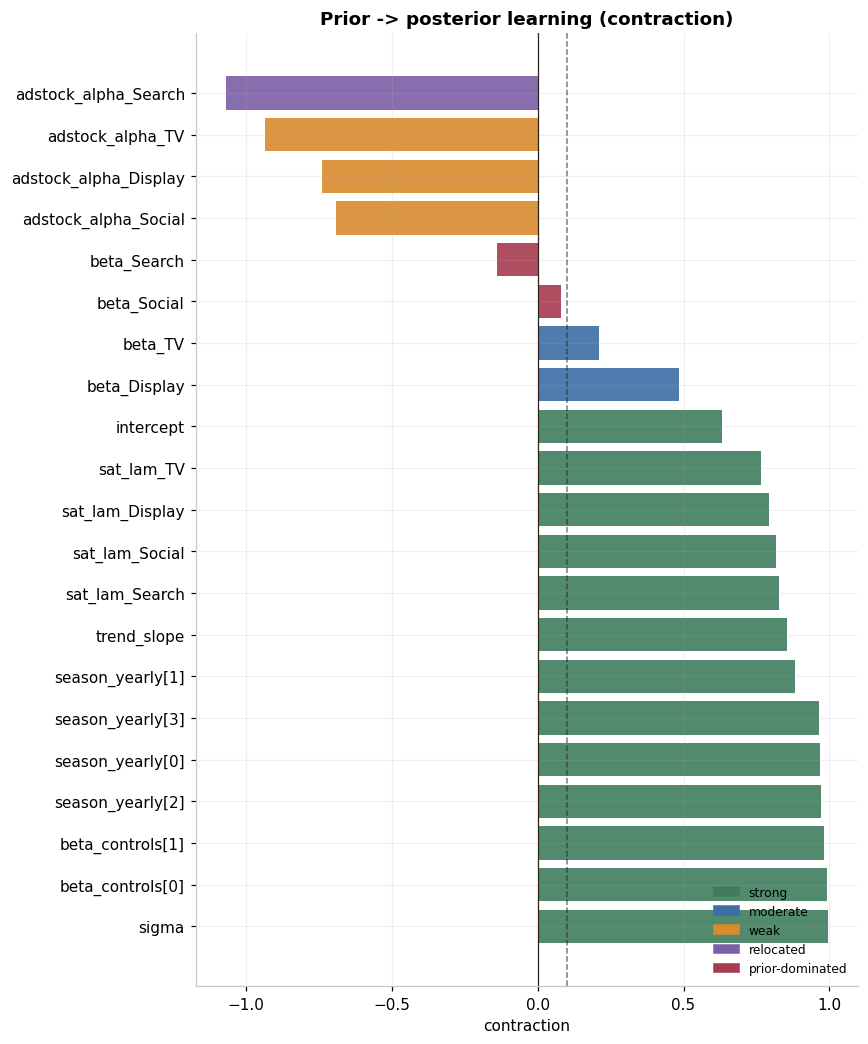

✓ Prior-dominated adstock weight: adstock_alpha_Search (contraction=-1.068, overlap=0.561, verdict='relocated')
  Meanwhile 13 ROI-driving parameters were strongly learned, e.g. ['intercept', 'sat_lam_TV', 'sat_lam_Display', 'sat_lam_Social', 'sat_lam_Search']


In [5]:
from mmm_framework.diagnostics import plot_parameter_learning

lrn = mmm.compute_parameter_learning(prior_samples=2000)   # base model takes no seed; posterior is seeded
display(lrn.round(3))

ax = plot_parameter_learning(lrn, threshold=0.1)
plt.tight_layout(); plt.show()

# The Beta(2,2) adstock BLEND WEIGHTS are barely updated by observational data
# (the carryover/saturation equifinality): the data hardly moves carryover.
ad = lrn[lrn.parameter.str.contains("adstock")]
assert (ad.contraction < 0.1).any(), f"expected a prior-dominated adstock weight; got\n{ad}"
pd_ad = ad[ad.contraction < 0.1].sort_values("contraction").iloc[0]
strong = lrn[lrn.contraction > 0.5].parameter.tolist()
print(f"✓ Prior-dominated adstock weight: {pd_ad.parameter} "
      f"(contraction={pd_ad.contraction:.3f}, overlap={pd_ad.overlap:.3f}, verdict='{pd_ad.verdict}')")
print(f"  Meanwhile {len(strong)} ROI-driving parameters were strongly learned, e.g. {strong[:5]}")

Read the bars honestly. The **adstock blend weights** sit at (or below) zero contraction with near-total prior
overlap — observational data barely moves *carryover*, a direct consequence of the carryover/saturation
equifinality. But the pieces that actually drive ROI — the **saturation** rates `sat_lam_*`, the **intercept**,
the **control** coefficients, the noise scale **sigma**, and the **seasonality** terms — are strongly learned
($c$ near 1). One channel even shows **negative** contraction: `beta_Search`, the demand-confounded channel
the model cannot pin — a genuine prior↔data tension flag, exactly the channel Chapter 1 warned about. So the
ROAS story rests on parameters the data informed; only the carryover shape leans on the prior.

## Does the model fit the data?

Before reading any contribution, check that the model actually tracks revenue. The shaded band is the
posterior credible interval on the prediction.

Sampling: [y_obs]


Output()

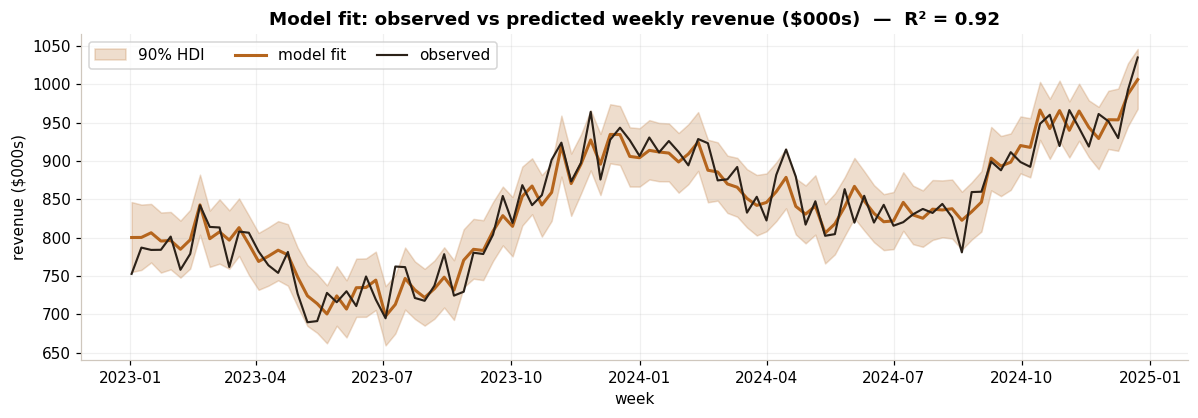

In [6]:
# Actual vs fitted revenue, with the posterior credible band.
pred = mmm.predict(return_original_scale=True, hdi_prob=0.9)
weeks = aurora.weeks
y = aurora.sales_total
r2 = 1 - np.sum((y - pred.y_pred_mean) ** 2) / np.sum((y - y.mean()) ** 2)
fig, ax = plt.subplots(figsize=(11, 3.9))
ax.fill_between(weeks, pred.y_pred_hdi_low, pred.y_pred_hdi_high, color=ACCENT, alpha=.22, label="90% HDI")
ax.plot(weeks, pred.y_pred_mean, color=ACCENT, lw=2, label="model fit")
ax.plot(weeks, y, color=INK, lw=1.4, label="observed")
ax.set_title(f"Model fit: observed vs predicted weekly revenue ($000s)  —  R² = {r2:.2f}")
ax.set_xlabel("week"); ax.set_ylabel("revenue ($000s)")
ax.legend(ncol=3, loc="upper left")
plt.tight_layout(); plt.show()

## Channel contributions — with credible intervals

The counterfactual contribution of a channel is how much revenue disappears if you turn it off. Every
number carries a posterior interval, so stakeholders see the *confidence*, not just the point.

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

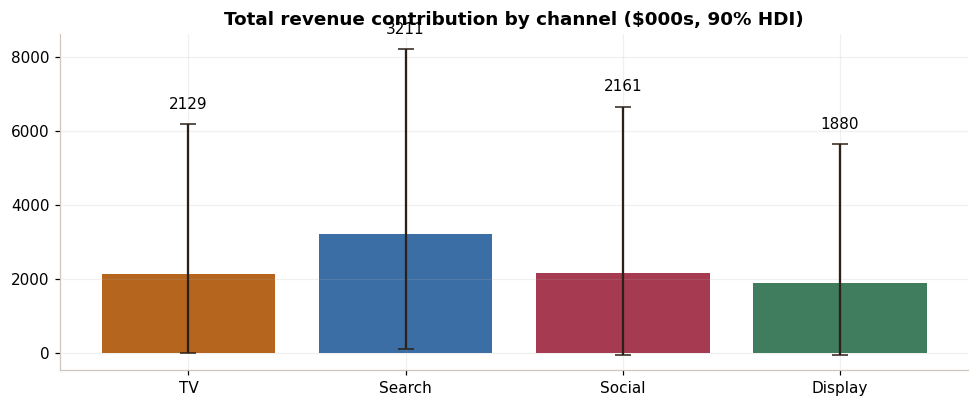

In [7]:
contrib = mmm.compute_counterfactual_contributions(compute_uncertainty=True, hdi_prob=0.9)
ct = contrib.total_contributions.loc[CHANNELS]
lo = contrib.contribution_hdi_low.loc[CHANNELS]; hi = contrib.contribution_hdi_high.loc[CHANNELS]

fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.bar(CHANNELS, ct, color=[CHANNEL_COLORS[c] for c in CHANNELS],
              yerr=[ct-lo, hi-ct], capsize=5, ecolor=INK)
ax.set_title("Total revenue contribution by channel ($000s, 90% HDI)")
ax.bar_label(bars, fmt="%.0f", padding=8)
plt.tight_layout(); plt.show()

Those totals come from *somewhere in time*. Stacking each channel's weekly contribution on top of the
non-media baseline shows when media drove revenue — and that the stack tracks the observed line.

Sampling: [y_obs]


Output()

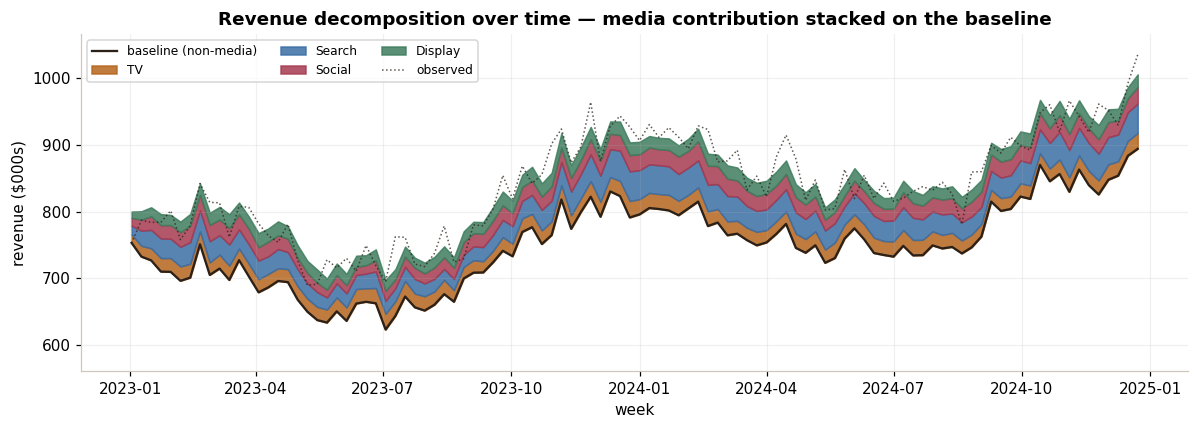

In [8]:
# Revenue decomposition over time. The baseline (everything non-media) is drawn as a LINE
# and each channel's counterfactual contribution is stacked on top — so the top of the
# stack IS the model's fitted revenue, which the observed series (dotted) tracks.
weeks = aurora.weeks
pred = mmm.predict(return_original_scale=True, hdi_prob=0.9)
cc = contrib.channel_contributions                          # DataFrame (n_obs x n_channels), >= 0
media_sum = np.asarray(cc[list(CHANNELS)].sum(axis=1), float)
baseline = np.asarray(pred.y_pred_mean, float) - media_sum  # non-media baseline (reconciles by construction)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(weeks, baseline, color=INK, lw=1.5, label="baseline (non-media)")
cum = baseline.copy()
for ch in CHANNELS:
    top = cum + np.asarray(cc[ch], float)
    ax.fill_between(weeks, cum, top, color=CHANNEL_COLORS[ch], alpha=.85, label=ch)
    cum = top
ax.plot(weeks, aurora.sales_total, color=INK, lw=1, ls=":", alpha=.75, label="observed")
ax.set_ylim(float(baseline.min()) * 0.90, float(max(cum.max(), aurora.sales_total.max())) * 1.03)
ax.set_title("Revenue decomposition over time — media contribution stacked on the baseline")
ax.set_xlabel("week"); ax.set_ylabel("revenue ($000s)")
ax.legend(ncol=3, loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## ROAS — return on ad spend

`MMMAnalyzer` turns contributions into ROI/ROAS (revenue per \$1 of spend), with the same uncertainty.

In [9]:
roi = MMMAnalyzer(mmm).compute_channel_roi().set_index("Channel").loc[CHANNELS]
roi["true ROAS"] = aurora.true_roas.loc[CHANNELS]
display(roi[["Total Spend", "Total Contribution", "ROI", "true ROAS"]].round(2))

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


...

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

,Total Spend,Total Contribution,ROI,true ROAS
Channel,,,,
TV,6053.78,2151.32,0.36,2.14
Search,3312.38,3224.13,0.97,0.66
Social,3095.75,2160.60,0.70,0.49
Display,2853.73,1872.96,0.66,2.11


The same table as a picture — ROAS with its credible interval, and the **true** ROAS as a diamond. The
model deflates the demand-chasers correctly, but the diamonds for TV and Display sit well above the bars.

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

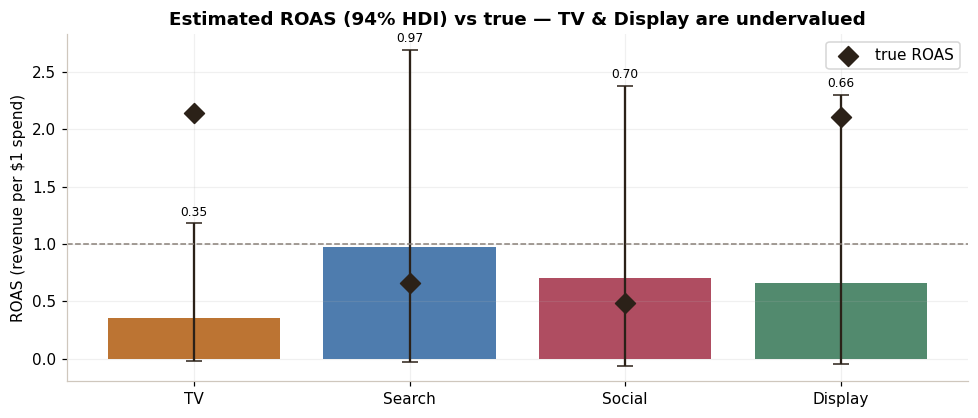

In [10]:
# ROAS with a 90% credible interval, against the oracle true ROAS.
chs = list(CHANNELS)
rfull = MMMAnalyzer(mmm).compute_channel_roi().set_index("Channel").loc[chs]
spend_ch = rfull["Total Spend"]
roas = rfull["ROI"]
roas_lo = rfull["Contribution HDI Low"] / spend_ch     # absolute HDI bound / spend
roas_hi = rfull["Contribution HDI High"] / spend_ch
tru = aurora.true_roas.loc[chs]
x = np.arange(len(chs))
fig, ax = plt.subplots(figsize=(9, 3.9))
bars = ax.bar(x, roas, color=[CHANNEL_COLORS[c] for c in chs], alpha=.9,
              yerr=[roas - roas_lo, roas_hi - roas], capsize=5, ecolor=INK)
ax.scatter(x, tru, marker="D", s=85, color=INK, zorder=4, label="true ROAS")
ax.axhline(1.0, color=MUTED, ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(chs)
ax.set_ylabel("ROAS (revenue per $1 spend)")
ax.set_title("Estimated ROAS (94% HDI) vs true — TV & Display are undervalued")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
ax.legend()
plt.tight_layout(); plt.show()

## Where does the *next* dollar go? (marginal ROAS)

Total ROAS is the average dollar. For budgeting you want the *marginal* dollar — what a +10% bump
returns — because saturation means channels don't scale forever.

In [11]:
marg = mmm.compute_marginal_contributions(spend_increase_pct=10, compute_uncertainty=True)
marg.set_index("Channel").loc[CHANNELS, ["Current Spend", "Marginal Contribution", "Marginal ROAS"]].round(2)

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


...

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

,Current Spend,Marginal Contribution,Marginal ROAS
Channel,,,
TV,6053.78,156.15,0.26
Search,3312.38,243.99,0.74
Social,3095.75,162.75,0.53
Display,2853.73,131.09,0.46


Average vs marginal, side by side: where the **next** dollar earns less than the average dollar already
spent, the channel is saturating. That gap is the budgeting signal.

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

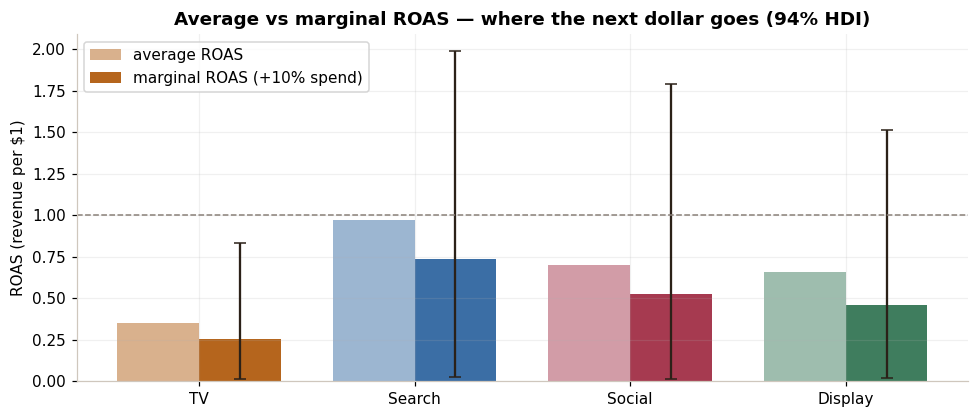

In [12]:
# Average ROAS (the dollar already spent) vs marginal ROAS (the next dollar).
chs = list(CHANNELS)
mm = marg.set_index("Channel").loc[chs]
avg = MMMAnalyzer(mmm).compute_channel_roi().set_index("Channel").loc[chs, "ROI"]
mroas = mm["Marginal ROAS"]
mlo, mhi = mm["Marginal ROAS HDI Low"], mm["Marginal ROAS HDI High"]
x = np.arange(len(chs)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 3.9))
ax.bar(x - w/2, avg, w, label="average ROAS",
       color=[CHANNEL_COLORS[c] for c in chs], alpha=.5)
b2 = ax.bar(x + w/2, mroas, w, label="marginal ROAS (+10% spend)",
            color=[CHANNEL_COLORS[c] for c in chs],
            yerr=[mroas - mlo, mhi - mroas], capsize=4, ecolor=INK)
ax.axhline(1.0, color=MUTED, ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(chs)
ax.set_ylabel("ROAS (revenue per $1)")
ax.set_title("Average vs marginal ROAS — where the next dollar goes (94% HDI)")
ax.legend()
plt.tight_layout(); plt.show()

## A what-if: move 20% of Search into TV

*Watch the sign.* The **base** model still undervalues TV, so it will judge this move a
**loss** — exactly the wrong call. Hold that thought; Chapter 3 explains why.

In [13]:
scenario = mmm.what_if_scenario({"Search": 0.8, "TV": 1.2})
print(f"baseline revenue : ${scenario['baseline_outcome']:,.0f}k")
print(f"scenario revenue : ${scenario['scenario_outcome']:,.0f}k")
print(f"change           : {scenario['outcome_change_pct']:+.2f}%  "
      f"(${scenario['outcome_change']:+,.0f}k)")

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: []


Sampling: []


baseline revenue : $87,306k
scenario revenue : $87,103k
change           : -0.23%  ($-204k)


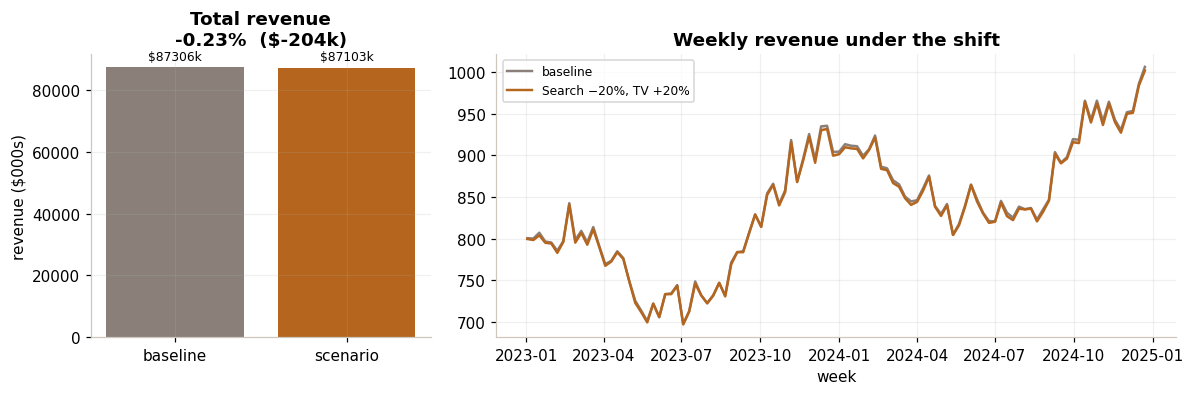

In [14]:
# The what-if, drawn: total impact and the week-by-week revenue path.
weeks = aurora.weeks
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.7), gridspec_kw={"width_ratios": [1, 2]})
ba = a1.bar(["baseline", "scenario"],
            [scenario["baseline_outcome"], scenario["scenario_outcome"]],
            color=[MUTED, ACCENT])
a1.bar_label(ba, fmt="$%.0fk", padding=3, fontsize=8)
a1.set_title(f"Total revenue\n{scenario['outcome_change_pct']:+.2f}%  "
             f"(${scenario['outcome_change']:+,.0f}k)")
a1.set_ylabel("revenue ($000s)")
a2.plot(weeks, scenario["baseline_prediction"], color=MUTED, lw=1.6, label="baseline")
a2.plot(weeks, scenario["scenario_prediction"], color=ACCENT, lw=1.6, label="Search −20%, TV +20%")
a2.fill_between(weeks, scenario["baseline_prediction"], scenario["scenario_prediction"],
                color=ACCENT, alpha=.18)
a2.set_title("Weekly revenue under the shift"); a2.set_xlabel("week")
a2.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## The honest caveat — and the cliffhanger

Compare the base model's ROAS to the truth: it nails Search/Social being modest, but it **badly
undervalues TV and Display**.

In [15]:
chk = pd.DataFrame({"base-model ROAS": roi["ROI"], "true ROAS": aurora.true_roas.loc[CHANNELS]})
chk["gap"] = chk["base-model ROAS"] - chk["true ROAS"]
chk.round(2)

,base-model ROAS,true ROAS,gap
TV,0.36,2.14,-1.79
Search,0.97,0.66,0.31
Social,0.70,0.49,0.21
Display,0.66,2.11,-1.45


That gap isn't noise. **TV and Display work almost entirely through brand awareness** — a pathway the
base model can't see, so it can't credit them for it. To value a brand channel you have to model the
mediation. That's **`03_extended_mmm.ipynb`**.

### Bonus — models are serializable
A fitted model (trace + config + experiment anchoring) round-trips to disk, so an expensive fit is
re-used downstream rather than re-run.

In [16]:
from pathlib import Path
from mmm_framework.serialization import MMMSerializer

Path("artifacts").mkdir(exist_ok=True)
MMMSerializer.save(mmm, "artifacts/aurora_base")
reloaded = MMMSerializer.load("artifacts/aurora_base", panel)
print("reloaded model channels:", reloaded.channel_names, "| trace restored:", reloaded._trace is not None)

reloaded model channels: ['TV', 'Search', 'Social', 'Display'] | trace restored: True


### Takeaways
- The base Bayesian MMM gives **contributions, ROAS, and marginal ROAS — all with credible intervals**.
- Diagnostics (`R̂`, ESS, divergences) keep the uncertainty *honest*.
- It correctly deflates the demand-chasing channels **but undervalues brand channels** that work through
  a mediator — which is exactly what Chapter 3 fixes.